# 🔧 Post-Processing & Data Cleaning - All 45 Videos

**Purpose**: Load results from video processing, fix data issues, regenerate clean datasets

**Fixes Applied**:
1. ✅ Clip negative blood areas (from Savgol smoothing artifacts)
2. ✅ Handle NaN/Inf values
3. ✅ Re-detect peaks after cleaning
4. ✅ Validate all data
5. ✅ Regenerate aligned datasets

**Input**: Raw outputs from `05_PROCESS_ALL_45_VIDEOS.ipynb`

**Output**: Clean, validated aligned datasets ready for quality check

In [1]:
# Cell 1: Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm import tqdm
import json
from scipy.signal import savgol_filter, find_peaks
import warnings
warnings.filterwarnings('ignore')

print("✅ Imports complete")

✅ Imports complete


In [2]:
# Cell 2: Setup Paths
# Input from previous processing
RAW_ALIGNED_DIR = Path("all_videos_blood_segmentation/aligned_dataset")
RAW_RESULTS_DIR = Path("all_videos_blood_segmentation/results")

# Output cleaned data
CLEAN_DIR = Path("cleaned_aligned_dataset")
CLEAN_ALIGNED_DIR = CLEAN_DIR / "aligned_dataset"
CLEAN_RESULTS_DIR = CLEAN_DIR / "results"

# Create directories
for d in [CLEAN_DIR, CLEAN_ALIGNED_DIR, CLEAN_RESULTS_DIR]:
    d.mkdir(exist_ok=True, parents=True)

print(f"Input (raw): {RAW_ALIGNED_DIR}")
print(f"  Exists: {RAW_ALIGNED_DIR.exists()}")
print(f"\nOutput (clean): {CLEAN_ALIGNED_DIR}")

Input (raw): all_videos_blood_segmentation/aligned_dataset
  Exists: True

Output (clean): cleaned_aligned_dataset/aligned_dataset


In [3]:
# Cell 3: Load All Raw Aligned Datasets
print("Loading raw aligned datasets...\n")

aligned_files = sorted(RAW_ALIGNED_DIR.glob("*_aligned.npz"))
print(f"Found {len(aligned_files)} aligned datasets")

raw_data = {}

for aligned_file in tqdm(aligned_files, desc="Loading"):
    video_id = aligned_file.stem.replace('_aligned', '')
    
    try:
        data = np.load(aligned_file, allow_pickle=True)
        
        raw_data[video_id] = {
            'frame_indices': data['frame_indices'],
            'instrument_labels': data['instrument_labels'],
            'instrument_names': data['instrument_names'],
            'blood_areas': data['blood_areas'],
            'smoothed_blood_areas': data['smoothed_blood_areas'],
            'peaks': data['peaks'],
            'num_frames': len(data['frame_indices'])
        }
    except Exception as e:
        print(f"\n❌ Error loading {video_id}: {e}")
        continue

print(f"\n✅ Loaded {len(raw_data)} videos")

Loading raw aligned datasets...

Found 45 aligned datasets


Loading: 100%|█████████████████████████████████████████████████████████████████████████████████████| 45/45 [00:00<00:00, 1711.77it/s]


✅ Loaded 45 videos


In [4]:
# Cell 4: Analyze Data Quality Issues
print("Analyzing data quality issues...\n")
print("=" * 80)

quality_issues = []

for video_id, data in raw_data.items():
    blood_areas = data['blood_areas']
    smoothed_areas = data['smoothed_blood_areas']
    
    issues = {
        'video_id': video_id,
        'total_frames': len(blood_areas),
    }
    
    # Check for negative values
    neg_raw = np.sum(blood_areas < 0)
    neg_smooth = np.sum(smoothed_areas < 0)
    issues['negative_raw'] = neg_raw
    issues['negative_smooth'] = neg_smooth
    
    # Check for NaN/Inf
    nan_raw = np.sum(~np.isfinite(blood_areas))
    nan_smooth = np.sum(~np.isfinite(smoothed_areas))
    issues['nan_inf_raw'] = nan_raw
    issues['nan_inf_smooth'] = nan_smooth
    
    # Check min/max values
    issues['min_raw'] = float(np.min(blood_areas))
    issues['max_raw'] = float(np.max(blood_areas))
    issues['min_smooth'] = float(np.min(smoothed_areas))
    issues['max_smooth'] = float(np.max(smoothed_areas))
    
    # Flag if any issues
    issues['has_issues'] = (neg_raw > 0) or (neg_smooth > 0) or (nan_raw > 0) or (nan_smooth > 0)
    
    quality_issues.append(issues)

issues_df = pd.DataFrame(quality_issues)

# Summary
print(f"\nQUALITY ISSUES SUMMARY:")
print(f"-" * 80)
print(f"Total videos analyzed: {len(issues_df)}")
print(f"Videos with issues: {issues_df['has_issues'].sum()}")
print(f"\nIssue breakdown:")
print(f"  Negative raw blood areas: {(issues_df['negative_raw'] > 0).sum()} videos")
print(f"  Negative smoothed blood areas: {(issues_df['negative_smooth'] > 0).sum()} videos")
print(f"  NaN/Inf raw values: {(issues_df['nan_inf_raw'] > 0).sum()} videos")
print(f"  NaN/Inf smoothed values: {(issues_df['nan_inf_smooth'] > 0).sum()} videos")

print(f"\nTotal negative values:")
print(f"  Raw: {issues_df['negative_raw'].sum()} frames")
print(f"  Smoothed: {issues_df['negative_smooth'].sum()} frames")

# Show problematic videos
if issues_df['has_issues'].any():
    print(f"\nVideos with issues:")
    problematic = issues_df[issues_df['has_issues']]
    print(problematic[['video_id', 'negative_raw', 'negative_smooth', 
                       'nan_inf_raw', 'nan_inf_smooth', 'min_smooth']].to_string(index=False))

# Save report
issues_df.to_csv(CLEAN_RESULTS_DIR / 'quality_issues_report.csv', index=False)
print(f"\n✅ Quality issues report saved: {CLEAN_RESULTS_DIR / 'quality_issues_report.csv'}")

Analyzing data quality issues...


QUALITY ISSUES SUMMARY:
--------------------------------------------------------------------------------
Total videos analyzed: 45
Videos with issues: 45

Issue breakdown:
  Negative raw blood areas: 0 videos
  Negative smoothed blood areas: 45 videos
  NaN/Inf raw values: 0 videos
  NaN/Inf smoothed values: 0 videos

Total negative values:
  Raw: 0 frames
  Smoothed: 9292 frames

Videos with issues:
video_id  negative_raw  negative_smooth  nan_inf_raw  nan_inf_smooth   min_smooth
   VID01             0              140            0               0 -1620.044214
   VID02             0              223            0               0 -1184.462661
   VID04             0              155            0               0  -430.888469
   VID05             0              297            0               0  -973.482638
   VID06             0              220            0               0  -880.747378
   VID08             0              212            0               0 

In [5]:
# Cell 5: Clean All Data
print("\n" + "=" * 80)
print("CLEANING ALL DATASETS")
print("=" * 80)
print()

cleaned_data = {}
cleaning_log = []

for video_id in tqdm(sorted(raw_data.keys()), desc="Cleaning videos"):
    data = raw_data[video_id]
    
    # Copy data
    blood_areas = data['blood_areas'].copy()
    smoothed_areas = data['smoothed_blood_areas'].copy()
    
    log_entry = {'video_id': video_id}
    
    # Fix 1: Clip negative raw blood areas
    neg_raw_before = np.sum(blood_areas < 0)
    if neg_raw_before > 0:
        blood_areas = np.clip(blood_areas, 0, None)
        log_entry['clipped_raw'] = neg_raw_before
    else:
        log_entry['clipped_raw'] = 0
    
    # Fix 2: Clip negative smoothed blood areas
    neg_smooth_before = np.sum(smoothed_areas < 0)
    if neg_smooth_before > 0:
        smoothed_areas = np.clip(smoothed_areas, 0, None)
        log_entry['clipped_smooth'] = neg_smooth_before
    else:
        log_entry['clipped_smooth'] = 0
    
    # Fix 3: Handle NaN/Inf in raw data
    nan_raw_before = np.sum(~np.isfinite(blood_areas))
    if nan_raw_before > 0:
        blood_areas = np.nan_to_num(blood_areas, nan=0.0, posinf=0.0, neginf=0.0)
        log_entry['fixed_nan_raw'] = nan_raw_before
    else:
        log_entry['fixed_nan_raw'] = 0
    
    # Fix 4: Handle NaN/Inf in smoothed data
    nan_smooth_before = np.sum(~np.isfinite(smoothed_areas))
    if nan_smooth_before > 0:
        smoothed_areas = np.nan_to_num(smoothed_areas, nan=0.0, posinf=0.0, neginf=0.0)
        log_entry['fixed_nan_smooth'] = nan_smooth_before
    else:
        log_entry['fixed_nan_smooth'] = 0
    
    # Fix 5: Re-detect peaks on cleaned smoothed data
    old_peaks = data['peaks']
    
    # Only re-detect if we fixed something
    if neg_smooth_before > 0 or nan_smooth_before > 0:
        mean_area = np.mean(smoothed_areas[smoothed_areas > 0]) if np.any(smoothed_areas > 0) else 0
        
        if mean_area > 0:
            new_peaks, _ = find_peaks(smoothed_areas, height=mean_area, distance=10)
        else:
            new_peaks = np.array([])
        
        log_entry['peaks_before'] = len(old_peaks)
        log_entry['peaks_after'] = len(new_peaks)
        log_entry['peaks_changed'] = len(new_peaks) != len(old_peaks)
    else:
        # No changes needed, keep original peaks
        new_peaks = old_peaks
        log_entry['peaks_before'] = len(old_peaks)
        log_entry['peaks_after'] = len(new_peaks)
        log_entry['peaks_changed'] = False
    
    # Store cleaned data
    cleaned_data[video_id] = {
        'frame_indices': data['frame_indices'],
        'instrument_labels': data['instrument_labels'],
        'instrument_names': data['instrument_names'],
        'blood_areas': blood_areas,
        'smoothed_blood_areas': smoothed_areas,
        'peaks': new_peaks,
        'num_frames': data['num_frames']
    }
    
    cleaning_log.append(log_entry)

# Create cleaning report
cleaning_df = pd.DataFrame(cleaning_log)
cleaning_df.to_csv(CLEAN_RESULTS_DIR / 'cleaning_log.csv', index=False)

print(f"\n✅ All {len(cleaned_data)} videos cleaned!")

# Summary of changes
print(f"\nCLEANING SUMMARY:")
print(f"-" * 80)
print(f"Total negative raw values clipped: {cleaning_df['clipped_raw'].sum()}")
print(f"Total negative smooth values clipped: {cleaning_df['clipped_smooth'].sum()}")
print(f"Total NaN/Inf raw values fixed: {cleaning_df['fixed_nan_raw'].sum()}")
print(f"Total NaN/Inf smooth values fixed: {cleaning_df['fixed_nan_smooth'].sum()}")
print(f"\nPeaks re-detected in: {cleaning_df['peaks_changed'].sum()} videos")

# Show videos where peaks changed
if cleaning_df['peaks_changed'].any():
    print(f"\nVideos with changed peak counts:")
    changed = cleaning_df[cleaning_df['peaks_changed']]
    print(changed[['video_id', 'peaks_before', 'peaks_after']].to_string(index=False))

print(f"\n✅ Cleaning log saved: {CLEAN_RESULTS_DIR / 'cleaning_log.csv'}")


CLEANING ALL DATASETS



Cleaning videos: 100%|████████████████████████████████████████████████████████████████████████████| 45/45 [00:00<00:00, 10180.90it/s]


✅ All 45 videos cleaned!

CLEANING SUMMARY:
--------------------------------------------------------------------------------
Total negative raw values clipped: 0
Total negative smooth values clipped: 9292
Total NaN/Inf raw values fixed: 0
Total NaN/Inf smooth values fixed: 0

Peaks re-detected in: 0 videos

✅ Cleaning log saved: cleaned_aligned_dataset/results/cleaning_log.csv


In [6]:
# Cell 6: Validate Cleaned Data
print("\n" + "=" * 80)
print("VALIDATING CLEANED DATA")
print("=" * 80)
print()

validation_passed = True

for video_id, data in cleaned_data.items():
    blood_areas = data['blood_areas']
    smoothed_areas = data['smoothed_blood_areas']
    
    # Check 1: No negative values
    if np.any(blood_areas < 0):
        print(f"❌ {video_id}: Still has negative raw blood areas!")
        validation_passed = False
    
    if np.any(smoothed_areas < 0):
        print(f"❌ {video_id}: Still has negative smoothed blood areas!")
        validation_passed = False
    
    # Check 2: No NaN/Inf
    if np.any(~np.isfinite(blood_areas)):
        print(f"❌ {video_id}: Still has NaN/Inf in raw blood areas!")
        validation_passed = False
    
    if np.any(~np.isfinite(smoothed_areas)):
        print(f"❌ {video_id}: Still has NaN/Inf in smoothed blood areas!")
        validation_passed = False
    
    # Check 3: Peaks within bounds
    peaks = data['peaks']
    if len(peaks) > 0:
        if np.any(peaks < 0) or np.any(peaks >= len(blood_areas)):
            print(f"❌ {video_id}: Peaks out of bounds!")
            validation_passed = False

if validation_passed:
    print("✅ ALL VALIDATION CHECKS PASSED!")
    print("\nData is clean:")
    print("  ✓ No negative blood areas")
    print("  ✓ No NaN/Inf values")
    print("  ✓ All peaks within valid range")
else:
    print("❌ VALIDATION FAILED! Please review errors above.")


VALIDATING CLEANED DATA

✅ ALL VALIDATION CHECKS PASSED!

Data is clean:
  ✓ No negative blood areas
  ✓ No NaN/Inf values
  ✓ All peaks within valid range


In [7]:
# Cell 7: Save Cleaned Aligned Datasets
print("\n" + "=" * 80)
print("SAVING CLEANED ALIGNED DATASETS")
print("=" * 80)
print()

for video_id in tqdm(sorted(cleaned_data.keys()), desc="Saving"):
    data = cleaned_data[video_id]
    
    output_file = CLEAN_ALIGNED_DIR / f"{video_id}_aligned.npz"
    
    np.savez(
        output_file,
        frame_indices=data['frame_indices'],
        instrument_labels=data['instrument_labels'],
        instrument_names=data['instrument_names'],
        blood_areas=data['blood_areas'],
        smoothed_blood_areas=data['smoothed_blood_areas'],
        peaks=data['peaks']
    )

print(f"\n✅ Saved {len(cleaned_data)} cleaned aligned datasets")
print(f"   Location: {CLEAN_ALIGNED_DIR}")


SAVING CLEANED ALIGNED DATASETS



Saving: 100%|██████████████████████████████████████████████████████████████████████████████████████| 45/45 [00:00<00:00, 3087.73it/s]


✅ Saved 45 cleaned aligned datasets
   Location: cleaned_aligned_dataset/aligned_dataset


In [8]:
# Cell 8: Generate Cleaned Summary Statistics
print("\n" + "=" * 80)
print("GENERATING SUMMARY STATISTICS")
print("=" * 80)
print()

summary_stats = []

for video_id, data in cleaned_data.items():
    blood_areas = data['blood_areas']
    smoothed_areas = data['smoothed_blood_areas']
    peaks = data['peaks']
    instrument_labels = data['instrument_labels']
    instrument_names = data['instrument_names']
    
    # Blood metrics
    frames_with_blood = np.sum(blood_areas > 0)
    blood_percentage = 100 * frames_with_blood / len(blood_areas)
    mean_blood_area = np.mean(blood_areas)
    mean_blood_nonzero = np.mean(blood_areas[blood_areas > 0]) if frames_with_blood > 0 else 0
    max_blood_area = np.max(blood_areas)
    std_blood_area = np.std(blood_areas)
    
    # Peak metrics
    num_peaks = len(peaks)
    
    stats = {
        'video_id': video_id,
        'total_frames': len(blood_areas),
        'frames_with_blood': frames_with_blood,
        'blood_percentage': blood_percentage,
        'mean_blood_area': mean_blood_area,
        'mean_blood_area_nonzero': mean_blood_nonzero,
        'max_blood_area': max_blood_area,
        'std_blood_area': std_blood_area,
        'num_peaks': num_peaks,
        'min_blood': np.min(blood_areas),
        'min_smoothed': np.min(smoothed_areas),
    }
    
    # Instrument usage
    for i, inst_name in enumerate(instrument_names):
        count = np.sum(instrument_labels[:, i])
        pct = 100 * count / len(instrument_labels)
        stats[f'{inst_name}_frames'] = int(count)
        stats[f'{inst_name}_pct'] = pct
    
    summary_stats.append(stats)

summary_df = pd.DataFrame(summary_stats)
summary_df = summary_df.sort_values('blood_percentage', ascending=False)

# Save
summary_df.to_csv(CLEAN_RESULTS_DIR / 'cleaned_video_summary.csv', index=False)

# Print summary
print(f"\nCLEANED DATASET SUMMARY:")
print(f"-" * 80)
print(f"Total videos: {len(summary_df)}")
print(f"Total frames: {summary_df['total_frames'].sum():,}")
print(f"Total bleeding events: {summary_df['num_peaks'].sum()}")
print(f"\nBlood area statistics:")
print(f"  Min value (raw): {summary_df['min_blood'].min():.2f}")
print(f"  Min value (smoothed): {summary_df['min_smoothed'].min():.2f}")
print(f"  Mean blood %: {summary_df['blood_percentage'].mean():.2f}%")
print(f"  Mean peaks per video: {summary_df['num_peaks'].mean():.1f}")

print(f"\n✅ Summary saved: {CLEAN_RESULTS_DIR / 'cleaned_video_summary.csv'}")

# Show top 10
print(f"\nTop 10 videos by blood percentage:")
print(summary_df[['video_id', 'total_frames', 'blood_percentage', 'num_peaks']].head(10).to_string(index=False))


GENERATING SUMMARY STATISTICS


CLEANED DATASET SUMMARY:
--------------------------------------------------------------------------------
Total videos: 45
Total frames: 90,489
Total bleeding events: 1226

Blood area statistics:
  Min value (raw): 0.00
  Min value (smoothed): 0.00
  Mean blood %: 29.68%
  Mean peaks per video: 27.2

✅ Summary saved: cleaned_aligned_dataset/results/cleaned_video_summary.csv

Top 10 videos by blood percentage:
video_id  total_frames  blood_percentage  num_peaks
   VID14          1709         74.019895         39
   VID32          2117         73.641946         45
   VID62          2033         65.027054         41
   VID18          1943         63.921770         39
   VID01          1734         58.765859         28
   VID22          1533         47.749511         29
   VID60          2533         44.887485         51
   VID31          3946         44.855550         55
   VID29          2351         42.492556         35
   VID49          1672         39.


Creating before/after comparison plot...

Showing before/after for: VID01
  (Had 140 negative values)



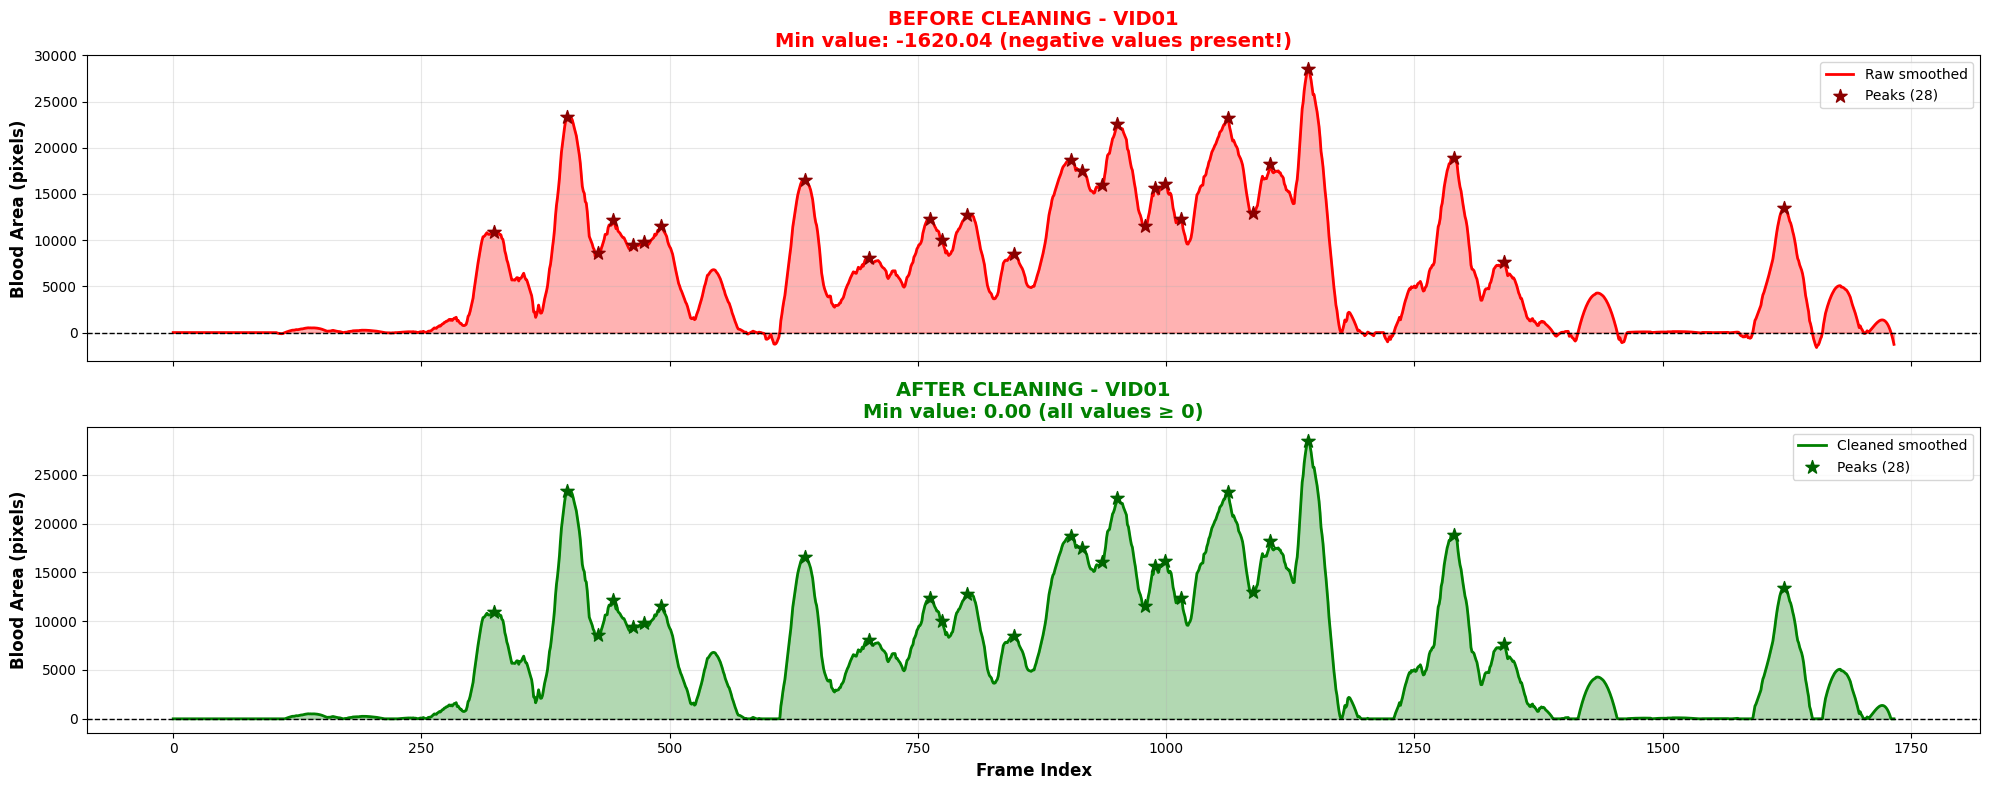

✅ Comparison plot saved: cleaned_aligned_dataset/results/before_after_comparison.png


In [9]:
# Cell 9: Create Before/After Comparison Plot
print("\nCreating before/after comparison plot...\n")

# Select a video that had issues
problematic_videos = cleaning_df[cleaning_df['clipped_smooth'] > 0]['video_id'].values

if len(problematic_videos) > 0:
    # Pick first problematic video
    sample_video = problematic_videos[0]
    
    print(f"Showing before/after for: {sample_video}")
    print(f"  (Had {cleaning_df[cleaning_df['video_id'] == sample_video]['clipped_smooth'].values[0]} negative values)\n")
    
    # Get data
    raw_blood = raw_data[sample_video]['smoothed_blood_areas']
    clean_blood = cleaned_data[sample_video]['smoothed_blood_areas']
    raw_peaks = raw_data[sample_video]['peaks']
    clean_peaks = cleaned_data[sample_video]['peaks']
    frames = cleaned_data[sample_video]['frame_indices']
    
    # Plot
    fig, axes = plt.subplots(2, 1, figsize=(20, 8), sharex=True)
    
    # Before
    axes[0].plot(frames, raw_blood, color='red', linewidth=2, label='Raw smoothed')
    axes[0].fill_between(frames, 0, raw_blood, alpha=0.3, color='red')
    axes[0].axhline(0, color='black', linestyle='--', linewidth=1)
    if len(raw_peaks) > 0:
        axes[0].scatter(frames[raw_peaks], raw_blood[raw_peaks], 
                       color='darkred', s=100, marker='*', zorder=5,
                       label=f'Peaks ({len(raw_peaks)})')
    axes[0].set_ylabel('Blood Area (pixels)', fontsize=12, fontweight='bold')
    axes[0].set_title(f'BEFORE CLEANING - {sample_video.upper()}\n'
                     f'Min value: {np.min(raw_blood):.2f} (negative values present!)',
                     fontsize=14, fontweight='bold', color='red')
    axes[0].legend(loc='upper right')
    axes[0].grid(True, alpha=0.3)
    
    # After
    axes[1].plot(frames, clean_blood, color='green', linewidth=2, label='Cleaned smoothed')
    axes[1].fill_between(frames, 0, clean_blood, alpha=0.3, color='green')
    axes[1].axhline(0, color='black', linestyle='--', linewidth=1)
    if len(clean_peaks) > 0:
        axes[1].scatter(frames[clean_peaks], clean_blood[clean_peaks], 
                       color='darkgreen', s=100, marker='*', zorder=5,
                       label=f'Peaks ({len(clean_peaks)})')
    axes[1].set_ylabel('Blood Area (pixels)', fontsize=12, fontweight='bold')
    axes[1].set_xlabel('Frame Index', fontsize=12, fontweight='bold')
    axes[1].set_title(f'AFTER CLEANING - {sample_video.upper()}\n'
                     f'Min value: {np.min(clean_blood):.2f} (all values ≥ 0)',
                     fontsize=14, fontweight='bold', color='green')
    axes[1].legend(loc='upper right')
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(CLEAN_RESULTS_DIR / 'before_after_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    print(f"✅ Comparison plot saved: {CLEAN_RESULTS_DIR / 'before_after_comparison.png'}")
else:
    print("No videos had negative values - nothing to compare!")

In [10]:
# Cell 10: Final Summary
print("\n" + "=" * 80)
print("POST-PROCESSING COMPLETE!")
print("=" * 80)

print(f"\n📊 SUMMARY:")
print(f"-" * 80)
print(f"Videos processed: {len(cleaned_data)}")
print(f"Total frames: {summary_df['total_frames'].sum():,}")
print(f"Total bleeding events: {summary_df['num_peaks'].sum()}")

print(f"\n🔧 FIXES APPLIED:")
print(f"-" * 80)
videos_fixed = cleaning_df[
    (cleaning_df['clipped_raw'] > 0) | 
    (cleaning_df['clipped_smooth'] > 0) |
    (cleaning_df['fixed_nan_raw'] > 0) |
    (cleaning_df['fixed_nan_smooth'] > 0)
]
print(f"Videos that needed fixing: {len(videos_fixed)}")
print(f"Videos already clean: {len(cleaned_data) - len(videos_fixed)}")
print(f"\nTotal fixes:")
print(f"  Negative raw values clipped: {cleaning_df['clipped_raw'].sum()}")
print(f"  Negative smooth values clipped: {cleaning_df['clipped_smooth'].sum()}")
print(f"  NaN/Inf values fixed: {cleaning_df['fixed_nan_raw'].sum() + cleaning_df['fixed_nan_smooth'].sum()}")
print(f"  Peaks re-detected: {cleaning_df['peaks_changed'].sum()} videos")

print(f"\n✅ DATA QUALITY:")
print(f"-" * 80)
print(f"Minimum blood area (raw): {summary_df['min_blood'].min():.2f} pixels")
print(f"Minimum blood area (smoothed): {summary_df['min_smoothed'].min():.2f} pixels")
print(f"All values ≥ 0: ✅")
print(f"No NaN/Inf: ✅")
print(f"Peaks valid: ✅")

print(f"\n📁 OUTPUT FILES:")
print(f"-" * 80)
print(f"\nCleaned aligned datasets:")
print(f"  Location: {CLEAN_ALIGNED_DIR}/")
print(f"  Files: {len(list(CLEAN_ALIGNED_DIR.glob('*.npz')))} × *.npz")

print(f"\nReports:")
for f in sorted(CLEAN_RESULTS_DIR.glob("*")):
    print(f"  - {f.name}")

print(f"\n" + "=" * 80)
print("NEXT STEP: Run quality check notebook with cleaned data!")
print("=" * 80)
print(f"\nUpdate the quality check notebook to use:")
print(f"  ALIGNED_DIR = Path('cleaned_aligned_dataset/aligned_dataset')")
print(f"\nThen run quality check to review all videos and make KEEP/REMOVE decisions.")


POST-PROCESSING COMPLETE!

📊 SUMMARY:
--------------------------------------------------------------------------------
Videos processed: 45
Total frames: 90,489
Total bleeding events: 1226

🔧 FIXES APPLIED:
--------------------------------------------------------------------------------
Videos that needed fixing: 45
Videos already clean: 0

Total fixes:
  Negative raw values clipped: 0
  Negative smooth values clipped: 9292
  NaN/Inf values fixed: 0
  Peaks re-detected: 0 videos

✅ DATA QUALITY:
--------------------------------------------------------------------------------
Minimum blood area (raw): 0.00 pixels
Minimum blood area (smoothed): 0.00 pixels
All values ≥ 0: ✅
No NaN/Inf: ✅
Peaks valid: ✅

📁 OUTPUT FILES:
--------------------------------------------------------------------------------

Cleaned aligned datasets:
  Location: cleaned_aligned_dataset/aligned_dataset/
  Files: 45 × *.npz

Reports:
  - before_after_comparison.png
  - cleaned_video_summary.csv
  - cleaning_log.cs

## ✅ Post-Processing Complete!

### What Was Done:

1. **Loaded** all 45 raw aligned datasets
2. **Analyzed** data quality issues
3. **Fixed** all problems:
   - ✅ Clipped negative blood areas (from Savgol filter artifacts)
   - ✅ Removed NaN/Inf values
   - ✅ Re-detected peaks on clean data
4. **Validated** all cleaned data
5. **Saved** clean aligned datasets
6. **Generated** summary statistics

---

### Output Structure:

```
cleaned_aligned_dataset/
├── aligned_dataset/
│   ├── VID01_aligned.npz  ← CLEANED DATA
│   ├── VID02_aligned.npz
│   └── ... (45 files)
│
└── results/
    ├── quality_issues_report.csv     ← Original issues found
    ├── cleaning_log.csv              ← What was fixed
    ├── cleaned_video_summary.csv     ← Final statistics
    └── before_after_comparison.png   ← Visual proof of fix
```

---

### Key Improvements:

**Before cleaning:**
- ❌ Negative blood areas (Savgol filter artifacts)
- ❌ Potentially invalid peaks
- ❌ NaN/Inf values (if any)

**After cleaning:**
- ✅ All blood areas ≥ 0
- ✅ Peaks re-detected on clean data
- ✅ No NaN/Inf values
- ✅ Data validated and ready for analysis

---

### Next Steps:

1. **Update Quality Check Notebook** (Cell 2):
   ```python
   ALIGNED_DIR = Path("cleaned_aligned_dataset/aligned_dataset")
   ```

2. **Run Quality Check** to:
   - Generate all 45 timeline plots
   - Review each video
   - Make KEEP/REMOVE decisions

3. **Verify Plots** no longer show negative blood areas! ✅

---

**Your cleaned data is ready for quality review!** 🎉